c:\Python310\lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Python310\lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Python310\lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


📊 Resultados do Hold-Out
Acurácia: 0.9649
Precisão: 0.9750
Recall: 0.9286
F1-score: 0.9512


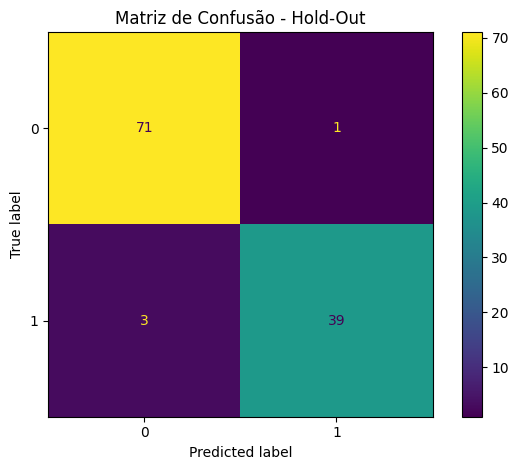

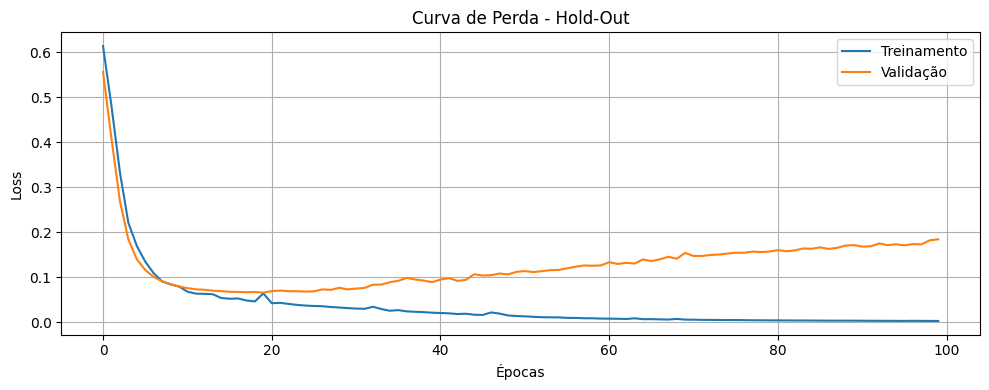

In [2]:
# Parte 4A — Hold-Out Tradicional com Métricas e Matriz de Confusão

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Carregamento e preparação dos dados
df = pd.read_csv('../data/breast_cancer.csv')
df = df.drop(columns=['id'], errors='ignore')
X = df.drop(columns='diagnosis')
y = df['diagnosis'].map({'M': 1, 'B': 0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=1.0, neginf=-1.0)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.values.reshape(-1, 1), test_size=0.2, stratify=y, random_state=42)

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

# Modelo com 2 camadas e 32 neurônios
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

model = NeuralNetwork(X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Treinamento
history = {'loss': [], 'val_loss': []}
for epoch in range(100):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        yb = yb.float().view(-1, 1)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    history['loss'].append(train_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            yb = yb.float().view(-1, 1)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
    history['val_loss'].append(val_loss / len(test_loader))

# Avaliação
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_bin = (y_pred > 0.5).float()

acc = accuracy_score(y_test, y_pred_bin.numpy())
prec = precision_score(y_test, y_pred_bin.numpy(), zero_division=0)
rec = recall_score(y_test, y_pred_bin.numpy(), zero_division=0)
f1 = f1_score(y_test, y_pred_bin.numpy(), zero_division=0)

print("📊 Resultados do Hold-Out")
print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_bin.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão - Hold-Out")
plt.grid(False)
plt.tight_layout()
plt.show()

# Curvas de perda
plt.figure(figsize=(10, 4))
plt.plot(history['loss'], label='Treinamento')
plt.plot(history['val_loss'], label='Validação')
plt.title("Curva de Perda - Hold-Out")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
